In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("../files/embalses_mes.csv")

In [12]:
df['FECHA'] = pd.to_datetime(df['FECHA'])

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7331 entries, 0 to 7330
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   AMBITO_NOMBRE     7331 non-null   str           
 1   FECHA             7331 non-null   datetime64[us]
 2   PORCENTAJE_LLENO  7329 non-null   float64       
 3   CATEGORIA         7331 non-null   str           
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 229.2 KB


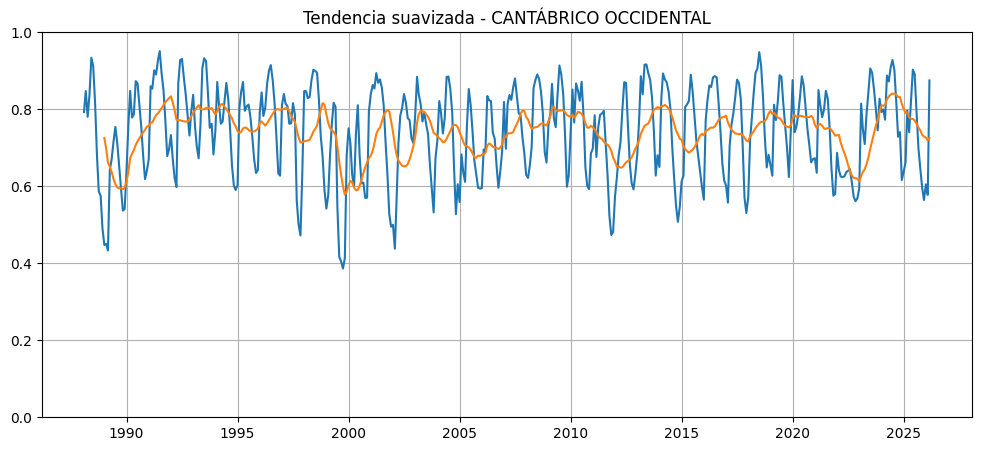

In [14]:
cuenca = "CANTÁBRICO OCCIDENTAL"

df_plot = df[df["AMBITO_NOMBRE"] == cuenca]

plt.figure(figsize=(12,5))
plt.plot(df_plot["FECHA"], df_plot["PORCENTAJE_LLENO"])

# media móvil 12 meses
plt.plot(
    df_plot["FECHA"],
    df_plot["PORCENTAJE_LLENO"].rolling(12).mean(),
)

plt.title(f"Tendencia suavizada - {cuenca}")
plt.ylim(0,1)
plt.grid(True)
plt.show()

In [15]:
df_volatilidad = (
    df
    .groupby("AMBITO_NOMBRE")["PORCENTAJE_LLENO"]
    .std()
    .sort_values(ascending=False)
)

df_volatilidad

AMBITO_NOMBRE
GUADALETE-BARBATE                  0.234872
GUADALQUIVIR                       0.223140
GUADIANA                           0.212452
CUENCAS INTERNAS DE CATALUÑA       0.208455
SEGURA                             0.164224
CUENCA MEDITERRÁNEA ANDALUZA       0.162649
DUERO                              0.153082
TINTO, ODIEL Y PIEDRAS             0.144724
CANTÁBRICO ORIENTAL                0.140138
JÚCAR                              0.138779
GALICIA COSTA                      0.135009
MIÑO - SIL                         0.134894
CUENCAS INTERNAS DEL PAÍS VASCO    0.134047
EBRO                               0.128737
TAJO                               0.118958
CANTÁBRICO OCCIDENTAL              0.117758
Name: PORCENTAJE_LLENO, dtype: float64

Mayor desviación estándar = más vulnerable a sequías bruscas

In [16]:
df_minimos = (
    df
    .groupby("AMBITO_NOMBRE")["PORCENTAJE_LLENO"]
    .min()
    .sort_values()
)

df_minimos

AMBITO_NOMBRE
GUADALETE-BARBATE                  0.020934
TAJO                               0.062500
SEGURA                             0.072356
JÚCAR                              0.073823
GUADIANA                           0.090856
GUADALQUIVIR                       0.094356
CUENCA MEDITERRÁNEA ANDALUZA       0.102650
CUENCAS INTERNAS DE CATALUÑA       0.149557
CANTÁBRICO ORIENTAL                0.181818
DUERO                              0.296190
TINTO, ODIEL Y PIEDRAS             0.311828
GALICIA COSTA                      0.328216
MIÑO - SIL                         0.330099
EBRO                               0.352371
CANTÁBRICO OCCIDENTAL              0.386157
CUENCAS INTERNAS DEL PAÍS VASCO    0.438095
Name: PORCENTAJE_LLENO, dtype: float64

qué cuencas han tenido peores mínimos históricos

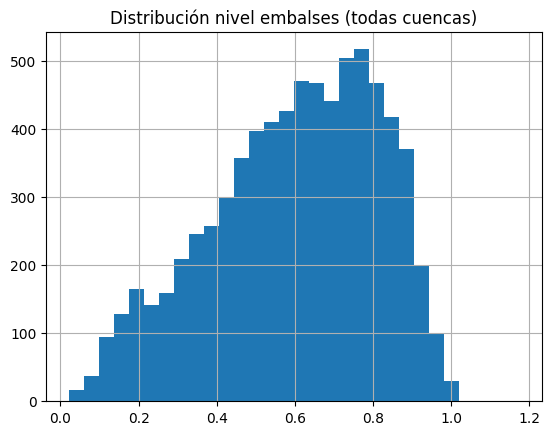

In [17]:
df["PORCENTAJE_LLENO"].hist(bins=30)
plt.title("Distribución nivel embalses (todas cuencas)")
plt.show()

la distribución tiene cola a la izquierda
- La mayoría del tiempo las cuencas están bastante llenas
- Pcasionalmente ocurren sequías severas
- Esos episodios son extremos pero poco frecuentes

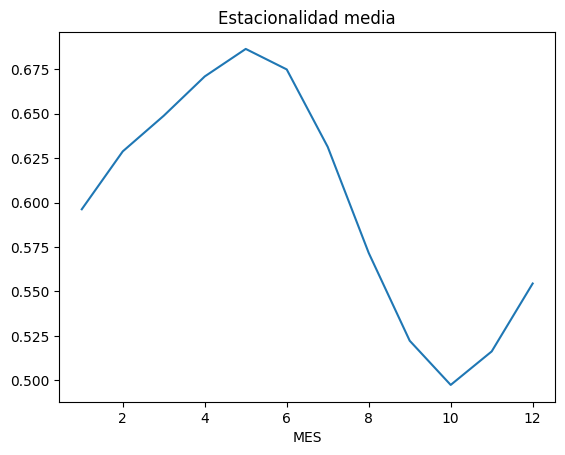

In [18]:
df["MES"] = df["FECHA"].dt.month

df_estacionalidad = (
    df
    .groupby("MES")["PORCENTAJE_LLENO"]
    .mean()
)

df_estacionalidad.plot()
plt.title("Estacionalidad media")
plt.show()